<a href="https://colab.research.google.com/github/Andreaa27/Telecom-analysis/blob/main/S7_Version_Estudiante_Project_ConnectaTel_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [53]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [54]:
# cargar archivos

plans = pd.read_csv('datasets/plans.csv')
users = pd.read_csv('datasets/users_latam.csv')
usage = pd.read_csv('datasets/usage.csv')


In [55]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [56]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [57]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [58]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape )

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [59]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 260.0+ bytes


In [60]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [61]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [62]:
# cantidad de nulos para users
print("Cantidad de valores nulos:\n", users.isnull().sum())
print()
print("Proporción de valores nulos\n",users.isnull().mean())


Cantidad de valores nulos:
 user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos
 user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [63]:
# cantidad de nulos para usage
print("Cantidad de valores nulos:\n", usage.isnull().sum())
print()
print("Proporción de valores nulos:\n", usage.isnull().mean())


Cantidad de valores nulos:
 id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos:
 id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


### Tratamiento de valores faltantes

#### Dataset `users`

- **`city` (11.72%)**: Imputar como `"Desconocido"` para evitar pérdida de información.
- **`churn_date` (88.35%)**: Conservar como nulos, ya que indican usuarios activos.



#### Dataset `usage`

- **`date` (0.12%)**: Eliminar filas con nulos por falta de referencia temporal.
- **`duration` (55.19%)**: Mantener nulos, ya que los mensajes (`text`) no tienen duración.
- **`length` (44.74%)**: Mantener nulos, debido a que las llamadas (`call`) no generan texto.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [64]:
# explorar columnas numéricas de users
users[['user_id','age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


### Análisis de columnas numéricas
- La columna `user_id` contiene **4000 registros** y no presenta valores nulos. Los identificadores comienzan en **10000** y llegan hasta **13999**, lo que sugiere que los IDs fueron asignados de manera consecutiva. Además, debido a que el rango contiene exactamente 4000 valores posibles, no parece haber registros duplicados en esta columna.

- La columna `age` también cuenta con **4000 registros**, por lo que no hay datos faltantes. Sin embargo, se detecta un valor atípico o centinela de **-999**, el cual probablemente representa un error o un dato no disponible y debería tratarse antes de realizar el análisis.

  El 50% central de los usuarios se distribuye de manera lógica: el 25% de los clientes tiene menos de **32 años**, la mediana se encuentra en **47 años** y el 75% alcanza hasta los **63 años**. Esto indica que la mayor parte de los usuarios pertenece a una población adulta. Asimismo, la edad máxima registrada de forma válida es de **79 años**.

In [65]:
# explorar columnas numéricas de usage
usage[['id', 'user_id', 'duration', 'length']].describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` contienen los **40,000 registros** de interacciones y no presentan valores faltantes. La columna `id` muestra identificadores consecutivos del **1 al 40000**, mientras que `user_id` abarca un rango de **10000 a 13999**, lo que indica una correcta integridad referencial con la tabla de usuarios, sin registros de IDs inexistentes.

- La columna `duration` refleja la duración de las llamadas. Presenta un valor mínimo de **0.0 minutos**, posiblemente asociado a llamadas perdidas o no conectadas, y un máximo de **120 minutos**. Además, el 75% de las llamadas tiene una duración menor a **6.99 minutos**, lo que sugiere que la mayoría de las interacciones son de corta duración.

- La columna `length` representa la longitud de los mensajes. Contiene un valor mínimo de **0.0 caracteres**, correspondiente probablemente a registros de llamadas, y un valor máximo de **1490 caracteres**, el cual resulta atípico al superar ampliamente la longitud convencional de un mensaje de texto. Por ello, este valor extremo debería revisarse durante el proceso de detección y tratamiento de outliers.

In [66]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

# descripción estadística de columnas categóricas
users[columnas_user].describe()


,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


### Análisis de columnas categóricas


- La columna `city` presenta 7 ciudades únicas.  
La ciudad con mayor presencia comercial en el dataset es `Bogotá`, registrando una frecuencia máxima de 808 clientes.

- La columna `plan` contiene exactamente 2 planes comerciales únicos dentro de la base de datos de usuarios.  
El plan dominante es `Basico`, reflejando una preferencia mayoritaria con una frecuencia de 2595 usuarios registrados.

In [67]:
# explorar columna categórica de usage
usage['type'].describe()

,type
count,40000
unique,2
top,text
freq,22092


- La columna `type` cuenta con 2 valores únicos para categorizar el tipo de consumo en la red. El servicio predominante es el envío de mensajes (text), registrando una frecuencia de 22092 eventos.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
<br>En el dataset `users`, la columna `age` presenta un valor sentinel explícito de `-999`, identificado en el valor mínimo de la variable. Este valor no representa una edad válida y puede alterar los análisis estadísticos.

También en el dataset `users`, la columna `city` contiene registros con el carácter `?`.<br>
En el dataset `usage`, la columna `length` muestra un valor máximo atípico de `1490` caracteres, superando considerablemente la longitud típica de un SMS convencional.
- ¿Qué acción tomarías?
 <br>Para la columna `age`, se recomienda reemplazar el valor `-999` por `NaN` y posteriormente evaluar si conviene imputarlo utilizando la mediana o eliminar dichos registros del análisis.

Para la columna `city`, se recomienda estandarizar el carácter `?` reemplazándolo por `"Desconocido"` o por valores nulos.
Para la columna `length`, utilizar diagramas de caja (`boxplots`) para determinar si corresponden a anomalías o casos válidos excepcionales.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [68]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [69]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [70]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts(dropna=False)

,count
reg_date,
2024,1330
2023,1316
2022,1314
2026,40



En la columna `reg_date`, la mayoría de los registros se distribuyen de manera consistente entre los años válidos `2022`, `2023` y `2024`.  

Sin embargo, se detectaron `40` registros anómalos correspondientes al año `2026`, representando fechas futuras inconsistentes con el límite temporal definido por el dataset(`2024`).

In [71]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts(dropna=False)

,count
date,
2024.0,39950
NaN,50



En la columna `date`, el 100% de las fechas válidas corresponden exclusivamente al año `2024`, acumulando un total de `39,950` registros.  

Adicionalmente, se identificaron `50` valores nulos (`NaN`), los cuales probablemente están asociados a errores de captura.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos
<br>Sí. En el dataset `users`, se identificaron `40` registros correspondientes al año `2026`. Dado que el límite temporal es 2024, estos registros representan fechas futuras inconsistentes.
En el dataset `usage`, la distribución temporal se encuentra correctamente concentrada en el año `2024`. Sin embargo, se detectaron `50` valores nulos (`NaN`) en la columna de fechas.

- ¿Qué harías con ellas?

Para los registros del año `2026` en `users`, se recomienda eliminar dichas filas o, alternativamente, reemplazar las fechas inválidas por valores nulos para posteriormente imputarlas con una fecha representativa, siempre que el negocio lo autorice. Debido a que representan una proporción pequeña del dataset, su eliminación no afectaría significativamente el análisis.

Para los valores nulos en `usage`, se recomienda eliminar los registros, ya que sin una fecha válida no es posible asociar correctamente el consumo a un periodo temporal específico ni analizar patrones mensuales de comportamiento.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [72]:
# Reemplazar -999 por la mediana de age
age_mediana = users[users['age'] != -999]['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

,age
count,4000.000000
mean,48.136000
std,17.689919
min,18.000000
25%,33.000000
50%,48.000000
75%,63.000000
max,79.000000


In [73]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?", pd.NA)

# Verificar cambios (contar cuántos nulos e interrogaciones quedan)
print("Cantidad de NA en city:", users['city'].isna().sum())
print("Cantidad de '?' en city:", (users['city'] == "?").sum())

Cantidad de NA en city: 565
Cantidad de '?' en city: 0


In [74]:
# Marcar fechas futuras como NA para reg_date (Año > 2024)
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
print("Conteo de años remanentes:")
print(users['reg_date'].dt.year.value_counts(dropna=False))

Conteo de años remanentes:
reg_date
2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: count, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [75]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().sum())

,duration
type,
call,0
text,22076


In [76]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().sum())


,length
type,
call,17896
text,0



### Diagnóstico de mecanismos de ausencia (MAR) en `duration` y `length`




- La columna `duration` presenta `0` valores nulos para los registros de tipo `call`. Sin embargo, el `100%` de sus ausencias (`22,076` valores nulos) se concentra en eventos de tipo `text`.

Esto indica que los mensajes de texto no poseen una duración temporal asociada, por lo que la ausencia de datos responde a la naturaleza del servicio y no a errores de captura.




- La columna `length` registra `0` valores nulos en eventos de tipo `text`, mientras que el `100%` de sus valores faltantes (`17,896` nulos) se concentra en registros de tipo `call`.

Este comportamiento confirma que las llamadas telefónicas no generan información relacionada con longitud de caracteres.



### Justificación y decisión analítica

Los valores faltantes en ambas columnas pueden clasificarse como un mecanismo MAR (*Missing At Random*), ya que las ausencias están completamente explicadas por otra variable observada (`type`) y no por fallos aleatorios en la captura de información.

Por esta razón, se recomienda conservar estos registros como valores nulos. Imputarlos mediante medidas estadísticas como la media o la mediana introduciría sesgos artificiales y alteraría las métricas reales de consumo de ConnectaTel.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [77]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg(
    numero_total_mensajes=('is_text', 'sum'),
    numero_total_llamadas=('is_call', 'sum'),
    total_minutos_llamada=('duration', 'sum')
).reset_index()

# observar resultado
usage_agg.head(3)


,user_id,numero_total_mensajes,numero_total_llamadas,total_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [78]:

# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'numero_total_mensajes': 'cant_mensajes',
    'numero_total_llamadas': 'cant_llamadas',
    'total_minutos_llamada': 'cant_minutos_llamada'
})

# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [79]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [80]:
# Resumen estadístico de las columnas numéricas
print("--- Resumen Estadístico de Consumo por Usuario ---")
columnas_consumo = ['age','cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
print(user_profile[columnas_consumo].describe())



--- Resumen Estadístico de Consumo por Usuario ---
               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  4000.000000    3999.000000    3999.000000           3999.000000
mean     48.136000       5.524381       4.478120             23.317054
std      17.689919       2.358416       2.144238             18.168095
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       4.000000       3.000000             11.120000
50%      48.000000       5.000000       4.000000             19.780000
75%      63.000000       7.000000       6.000000             31.415000
max      79.000000      17.000000      15.000000            155.690000


In [81]:
# Distribución porcentual del tipo de plan
print("--- Distribución Porcentual de Planes ---")
dist_planes_porcentaje = user_profile['plan'].value_counts(normalize=True) * 100
print(dist_planes_porcentaje.map("{:.2f}%".format))


--- Distribución Porcentual de Planes ---
plan
Basico     64.88%
Premium    35.12%
Name: proportion, dtype: object


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

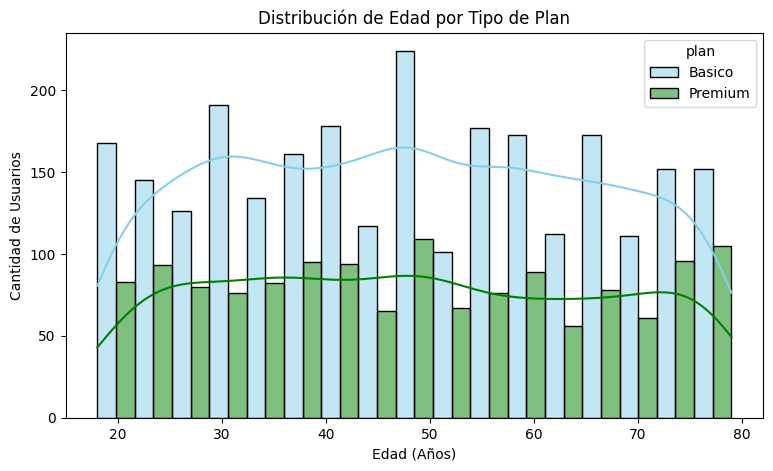

In [82]:
# Histograma para visualizar la edad (age)
plt.figure(figsize=(9, 5))
sns.histplot(data=user_profile, x='age', hue='plan', multiple='dodge', palette=['skyblue', 'green'], kde=True)

plt.title('Distribución de Edad por Tipo de Plan')
plt.xlabel('Edad (Años)')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights:
### Distribución de usuarios por edad y tipo de plan

El gráfico evidencia un claro predominio del plan `Básico` sobre el plan `Premium`, ya que el número de usuarios asociados al plan básico es considerablemente mayor en prácticamente todos los rangos de edad analizados.

#### Plan `Básico`


La distribución de usuarios del plan `Básico` presenta varios picos de concentración a lo largo de las edades. El más pronunciado se localiza alrededor de los `50 años`, consolidándose como el grupo de edad con mayor cantidad de clientes registrados.


También se observan incrementos secundarios en edades cercanas a los `30` y `40 años`, aunque con menor intensidad respecto al pico principal.


#### Plan `Premium`

En contraste, los usuarios del plan `Premium` muestran una distribución más homogénea y estable a lo largo de las edades.

Aunque existe un ligero incremento de usuarios cerca de los `50 años`, este comportamiento resulta mucho menos marcado que en el plan básico, reflejando una dispersión más uniforme de clientes en los distintos grupos de edad.

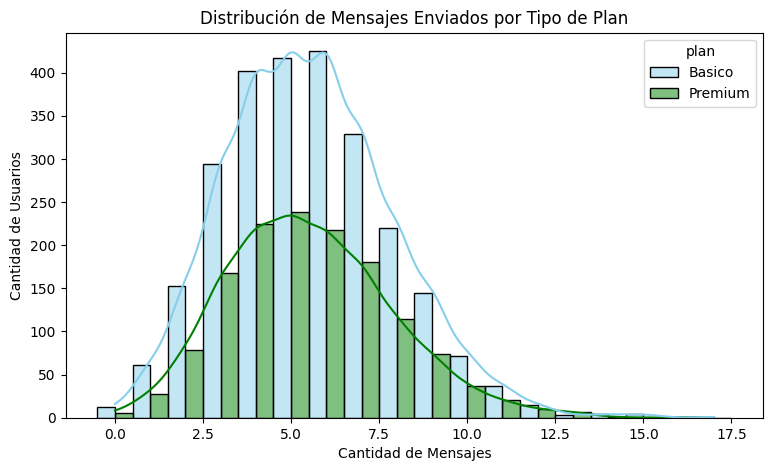

In [83]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(9, 5))

# Corregido el nombre de la columna a 'cant_mensajes'
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', multiple='dodge', palette=['skyblue', 'green'], kde=True, discrete=True)

plt.title('Distribución de Mensajes Enviados por Tipo de Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Cantidad de Usuarios')
plt.show()



💡Insights:


### Distribución del consumo de mensajes (`cant_mensajes`)

La variable `cant_mensajes` presenta una distribución con forma de campana en su zona central, similar a una distribución normal o gaussiana. Sin embargo, se observa un sesgo hacia la derecha (*right skew*), indicando que la mayoría de los usuarios mantiene un consumo bajo de mensajes, mientras que un grupo reducido concentra consumos más altos.

Este comportamiento se confirma al comparar la mediana (`alrededor de 5 mensajes`) con el valor máximo (`17 mensajes`), evidenciando que la mayor parte de los registros se encuentra en valores bajos de uso.



### Diferencias por tipo de plan

#### Plan `Premium`

La distribución correspondiente al plan `Premium` muestra una curva más suave, continua y uniforme, reflejando un patrón de comportamiento relativamente estable entre los usuarios.

#### Plan `Básico`

Por otro lado, el plan `Básico` presenta fluctuaciones y picos más pronunciados, especialmente entre los `4` y `6 mensajes`. Esto puede atribuirse al mayor volumen de clientes asociados a este plan, lo que hace más visible la variabilidad en los conteos discretos.



### Interpretación general

Los resultados sugieren que el servicio de SMS es poco utilizado por los clientes de ConnectaTel durante 2024, ya que la mayoría de los usuarios concentra su consumo en cantidades reducidas de mensajes.


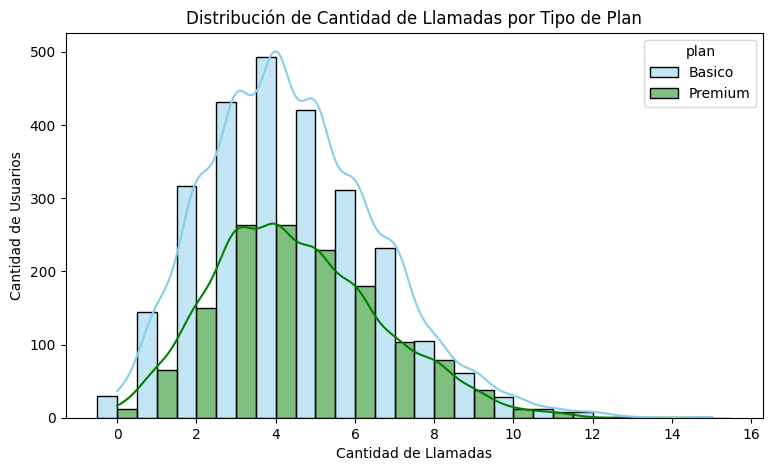

In [84]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(9, 5))

sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', multiple='dodge', palette=['skyblue', 'green'], kde=True, discrete=True)

plt.title('Distribución de Cantidad de Llamadas por Tipo de Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Cantidad de Usuarios')
plt.show()


💡Insights:
### Distribución del consumo de llamadas (`cant_llamadas`)

La variable `cant_llamadas` presenta una distribución con forma de campana y un pequeño sesgo hacia la derecha (*right skew*), mostrando un comportamiento muy similar al observado en el consumo de mensajes.

La mediana de llamadas se ubica alrededor de `4 llamadas mensuales`, mientras que en los mensajes el punto central se encontraba alrededor de `5 mensajes`. Esto sugiere que el usuario promedio de ConnectaTel mantiene un nivel de actividad moderado y relativamente equilibrado entre llamadas y SMS.


### Diferencias entre planes

#### Plan `Básico`

Las barras correspondientes al plan `Básico` presentan una mayor altura debido al volumen significativamente más alto de usuarios registrados en este segmento.

#### Plan `Premium`

Aunque el plan `Premium` cuenta con menos usuarios, la distribución mantiene una presencia relativamente estable en los rangos de consumo medio-alto, especialmente entre `6` y `10 llamadas`. Esto indica que una proporción importante de los clientes Premium utiliza activamente el servicio de llamadas.



### Presencia de valores extremos

La distribución se extiende hacia el extremo derecho debido a la presencia de algunos usuarios con consumos considerablemente superiores al promedio.

Se identifica un pequeño grupo de usuarios con comportamiento atípico que alcanza hasta `15 llamadas mensuales`, generando la asimetría positiva observada en la distribución.

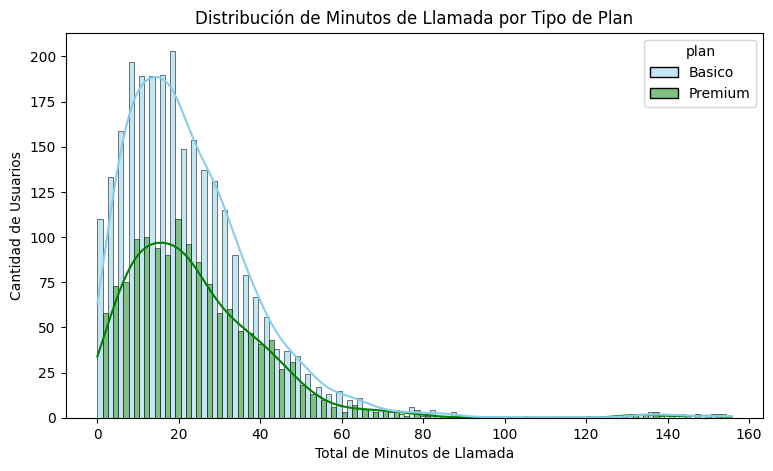

In [85]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(9, 5))

sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', multiple='dodge', palette=['skyblue', 'green'], kde=True)

plt.title('Distribución de Minutos de Llamada por Tipo de Plan')
plt.xlabel('Total de Minutos de Llamada')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights:

### Duración promedio y sesgo de la distribución

El análisis de la variable `duration` revela que no solo importa la cantidad de llamadas realizadas, sino también el tiempo total de conversación.  

- **Media general:** 23.31 minutos  
- **Mediana general:** 19.78 minutos  

La diferencia entre ambas métricas, calculadas sobre toda la distribución sin segmentar por tipo de plan, junto con la presencia de una cola extendida hacia la derecha, confirma un sesgo positivo (*right skew*).  

Este comportamiento está influenciado por un pequeño grupo de usuarios con consumos extremos, alcanzando hasta `155.69 minutos` mensuales.


### Comportamiento por plan

Al comparar las curvas de densidad entre los planes `Básico` (azul) y `Premium` (verde), ambas concentran su punto máximo en rangos muy similares, aproximadamente entre `10` y `25 minutos`.

Esto sugiere que pertenecer a un plan más costoso no modifica significativamente el patrón de consumo de la mayoría de los usuarios, ya que los clientes Premium no necesariamente hablan más minutos que los usuarios del plan Básico.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

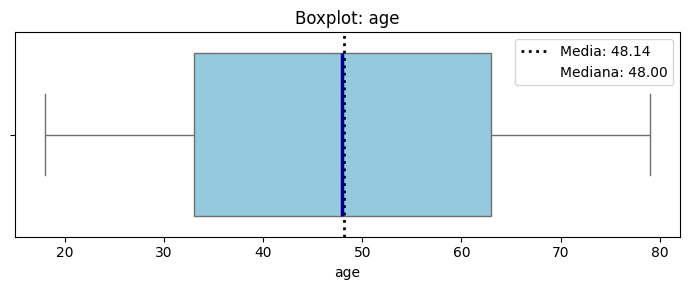

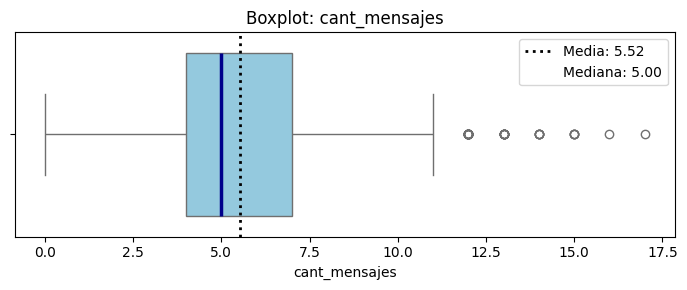

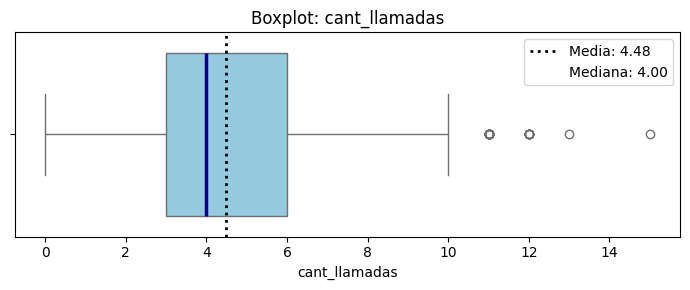

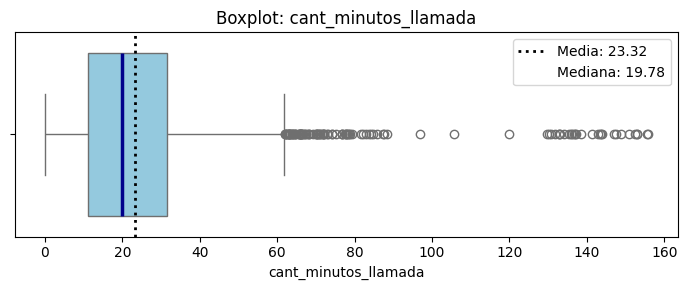

In [86]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(7, 3))

    media = user_profile[col].mean()
    mediana = user_profile[col].median()


    sns.boxplot(
        data=user_profile,
        x=col,
        color='skyblue',
        medianprops={'color': 'darkblue', 'linewidth': 2.5}
    )

    #  Dibujamos la línea punteada negra para la MEDIA
    plt.axvline(x=media, color='black', linestyle=':', linewidth=2, label=f'Media: {media:.2f}')

    #  Dibujamos una línea invisible o simplemente añadimos la MEDIANA a la leyenda
    plt.axvline(x=mediana, color='darkblue', linestyle='-', linewidth=0, label=f'Mediana: {mediana:.2f}')

    # Configuraciones estéticas del gráfico
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.legend(loc='upper right') # Muestra el cuadro informativo con los valores reales
    plt.tight_layout()
    plt.show()

💡Insights:
En este análisis se observan las distribuciones generales de las variables numéricas sin segmentarlas por tipo de plan, permitiendo identificar simetrías, sesgos y presencia de valores atípicos en el comportamiento global de los usuarios.


### Variable `age`

La variable `age` no presenta valores atípicos (*outliers*). La línea de la mediana (`48.00`) y la línea de la media (`48.14`) se encuentran prácticamente superpuestas en el centro de la caja, indicando una distribución altamente simétrica.

Esto confirma tanto visual como estadísticamente que las edades de los usuarios se distribuyen de manera homogénea, sin registros extremos que distorsionen las métricas centrales.

### Variable `cant_mensajes`

La variable `cant_mensajes` presenta valores atípicos hacia el extremo derecho de la distribución.

La media (`5.52`) se encuentra ligeramente desplazada respecto a la mediana (`5.00`), evidenciando un sesgo positivo moderado (*right skew*).  

En el diagrama de caja, los outliers aparecen a partir de aproximadamente `12 mensajes`, extendiéndose hasta un máximo de `17 mensajes`.


### Variable `cant_llamadas`

La variable `cant_llamadas` también presenta valores atípicos del lado derecho.

La media (`4.48`) supera ligeramente a la mediana (`4.00`), confirmando nuevamente un sesgo positivo en la distribución.  

Los registros atípicos comienzan a dispersarse después del límite superior del bigote, cercano a `10 llamadas`, identificándose usuarios que realizan entre `11` y `15 llamadas` mensuales.


### Variable `cant_minutos_llamada`

La variable `cant_minutos_llamada` presenta la mayor concentración de valores atípicos de todo el análisis.

La diferencia entre la media (`23.32`) y la mediana (`19.78`) evidencia un sesgo positivo mucho más pronunciado que en las demás variables.

El gráfico de caja muestra una alta densidad de puntos atípicos por encima del límite superior del bigote, ubicado aproximadamente en `62 minutos`. Estos registros se extienden de manera continua hasta alcanzar un máximo de `155.69 minutos`.

Este comportamiento sugiere la existencia de un segmento reducido pero importante de usuarios con consumos excepcionalmente altos de minutos de llamada.

In [87]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + (1.5 * IQR)

    print(f"Variable: {col}")
    print(f"  -> Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"  -> Límite Superior Teórico: {limite_superior:.2f}\n")


Variable: cant_mensajes
  -> Q1: 4.00, Q3: 7.00, IQR: 3.00
  -> Límite Superior Teórico: 11.50

Variable: cant_llamadas
  -> Q1: 3.00, Q3: 6.00, IQR: 3.00
  -> Límite Superior Teórico: 10.50

Variable: cant_minutos_llamada
  -> Q1: 11.12, Q3: 31.41, IQR: 20.30
  -> Límite Superior Teórico: 61.86



In [88]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000




💡 **Insights: Tratamiento y decisiones sobre valores atípicos (outliers)**

### Variable `cant_mensajes`

El método IQR estableció un límite superior teórico de `11.50 mensajes`, mientras que el valor máximo observado en la muestra alcanza `17.00 mensajes`.

A pesar de ser identificados estadísticamente como outliers, se decide conservar estos registros debido a que un consumo de `17 mensajes mensuales` continúa siendo completamente razonable y bajo dentro de un contexto real de telecomunicaciones.



### Variable `cant_llamadas`

Para la variable `cant_llamadas`, el límite superior calculado mediante IQR fue de `10.50 llamadas`, mientras que el máximo registrado corresponde a `15.00 llamadas`.

Estos registros también se mantienen en el análisis, ya que realizar hasta `15 llamadas mensuales` representa un comportamiento natural y esperado dentro de una base de clientes de servicios móviles. No existen indicios de errores de captura ni de corrupción de datos.



### Variable `cant_minutos_llamada`

La variable `cant_minutos_llamada` presenta el caso más extremo de valores atípicos. El límite superior teórico se ubicó en `61.86 minutos`, mientras que el valor máximo real alcanza `155.69 minutos`.

En este caso, la decisión analítica es conservar obligatoriamente dichos registros, ya que representan usuarios de alto consumo y gran valor comercial para ConnectaTel.

Eliminar estos registros provocaría una subestimación importante en futuros análisis de facturación, consumo excedente y estrategias de monetización.



## 📌 Nota metodológica sobre tendencia central y objetivos de negocio

La decisión de conservar o eliminar outliers depende directamente del objetivo analítico del proyecto.

### Cuando es recomendable conservarlos

Si el objetivo es analizar:
- patrones reales de consumo,
- usuarios intensivos,
- ingresos por sobreconsumo,
- comportamiento comercial,
- o estrategias de *upselling* hacia planes Premium,

entonces los valores atípicos deben mantenerse, ya que representan clientes reales y económicamente relevantes para la compañía.

---

### Cuando podría ser conveniente aislarlos

Si el objetivo consiste en modelar el comportamiento del “usuario promedio” o construir perfiles representativos del cliente típico, entonces podría ser conveniente aislar temporalmente estos registros.

Esto se debe a que los outliers desplazan la media hacia valores superiores, distorsionando la tendencia central de la mayoría de los usuarios. Por ejemplo:

- **Media de minutos:** `23.32`
- **Mediana de minutos:** `19.78`

La diferencia entre ambas métricas evidencia cómo los usuarios de consumo extremo afectan el promedio general.


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [89]:
# Crear columna grupo_uso
#  Definimos la función que evalúa cada renglón (usuario)
def segmentar_por_uso(row):
    llamadas = row['cant_llamadas']
    mensajes = row['cant_mensajes']

    if llamadas < 5 and mensajes < 5:
        return 'Bajo uso'
    elif llamadas < 10 and mensajes < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

#  Aplicamos la función a lo largo del DataFrame (axis=1 indica que lee fila por fila)
user_profile['grupo_uso'] = user_profile.apply(segmentar_por_uso, axis=1)


In [90]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [91]:
# Crear columna grupo_edad
#  Definimos la función para segmentar según la edad
def segmentar_por_edad(row):
    edad = row['age']

    if edad < 30:
        return 'Joven'
    elif edad < 60:
        return 'Adulto'
    else:
        return 'Adulto mayor'

# Aplicamos la función fila por fila en el DataFrame
user_profile['grupo_edad'] = user_profile.apply(segmentar_por_edad, axis=1)


In [92]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

/tmp/ipykernel_4338/1487330995.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=user_profile, x='grupo_uso', order=['Bajo uso', 'Uso medio', 'Alto uso'], palette='Blues_r')


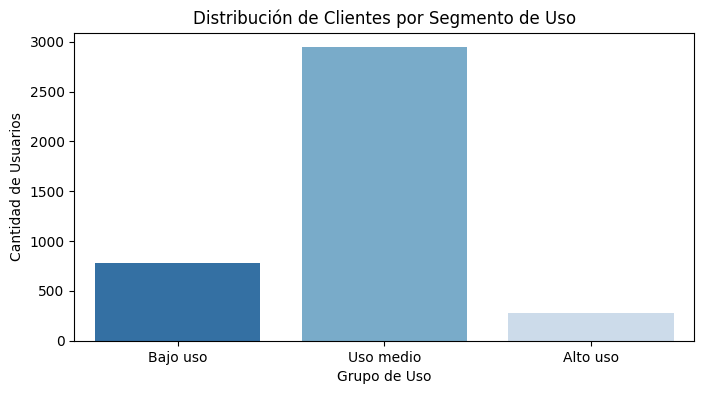

In [93]:
# Visualización de los segmentos por uso
plt.figure(figsize=(8, 4))
sns.countplot(data=user_profile, x='grupo_uso', order=['Bajo uso', 'Uso medio', 'Alto uso'], palette='Blues_r')

plt.title('Distribución de Clientes por Segmento de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()

/tmp/ipykernel_4338/1624428313.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=user_profile, x='grupo_edad', order=['Joven', 'Adulto', 'Adulto mayor'], palette='Greens_r')


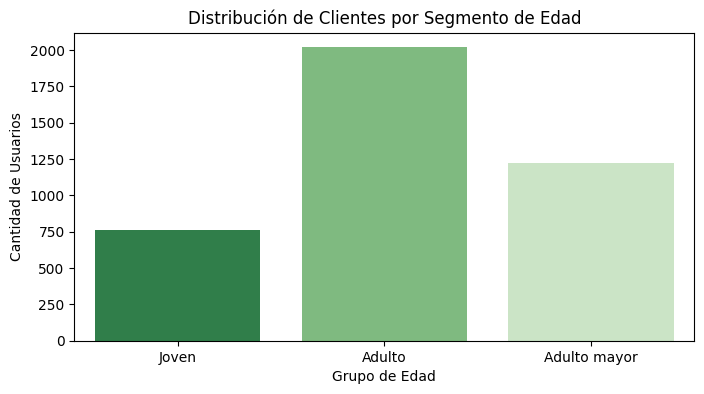

In [94]:
# Visualización de los segmentos por edad
plt.figure(figsize=(8, 4))
sns.countplot(data=user_profile, x='grupo_edad', order=['Joven', 'Adulto', 'Adulto mayor'], palette='Greens_r')

plt.title('Distribución de Clientes por Segmento de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()


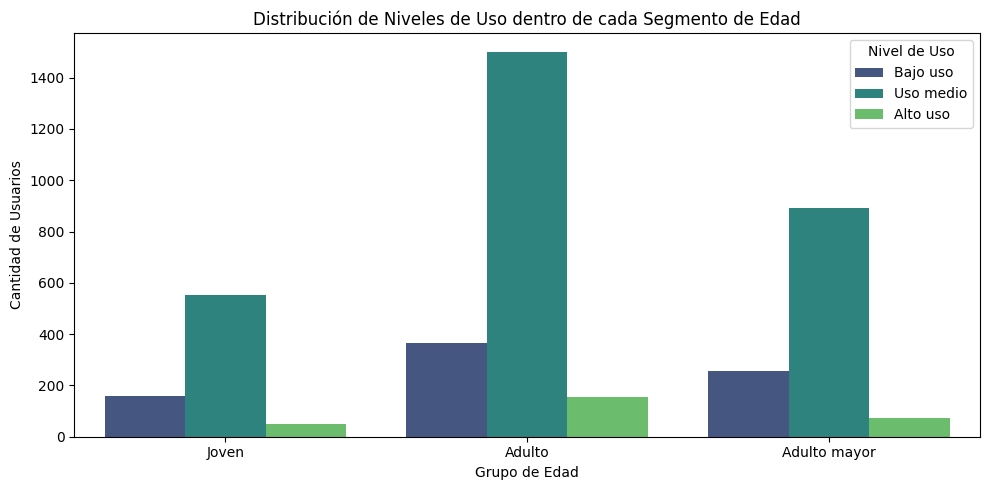

In [95]:
#Distribución de Niveles de Uso dentro de cada Segmento de Edad
plt.figure(figsize=(10, 5))

# Se usa 'grupo_edad' en el eje X y dividimos las barras con 'hue' usando 'grupo_uso'
sns.countplot(
    data=user_profile,
    x='grupo_edad',
    order=['Joven', 'Adulto', 'Adulto mayor'],
    hue='grupo_uso',
    hue_order=['Bajo uso', 'Uso medio', 'Alto uso'],
    palette='viridis'
)


plt.title('Distribución de Niveles de Uso dentro de cada Segmento de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.legend(title='Nivel de Uso', loc='upper right')
plt.tight_layout()
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.



**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se identificaron valores centinela (`-999`) en la columna `age`, los cuales fueron reemplazados utilizando la mediana general de edad (`48 años`).
- La columna `city` presentó un `11.72%` de registros inválidos con el carácter `?`, mismos que fueron estandarizados como valores nulos (`<NA>`).
- Se detectaron `40` registros con fechas futuras (`2026`) en `reg_date`, inconsistentes con el rango temporal válido del negocio (`2024`).
- Las columnas `duration` y `length` presentaron valores nulos masivos; sin embargo, se comprobó que corresponden a ausencias lógicas relacionadas con el tipo de interacción (`call` o `text`), por lo que fueron conservadas.



🔍 **Segmentos por Edad**
- El segmento dominante corresponde a adultos entre `30 y 59 años`, superando los `2,000 usuarios`.
- Los adultos mayores (`60+`) representan el segundo grupo más numeroso, mientras que los jóvenes constituyen la minoría de la base.
- La preferencia comercial se mantiene estable en todos los rangos de edad respecto a los planes (Básico y premium).



📊 **Segmentos por Nivel de Uso**
- La mayoría de los usuarios pertenece al segmento de **Uso medio**, realizando menos de `10 llamadas` y enviando menos de `10 mensajes` al mes.
- El servicio de SMS presenta un consumo extremadamente bajo; incluso el valor máximo registrado fue de apenas `17 mensajes`.
- Se identificó un pequeño grupo de usuarios intensivos con consumos elevados de minutos, alcanzando hasta `155.69 minutos` mensuales.


📊🔍**Segmentación por edad y nivel de uso**

El análisis muestra que el nivel de uso mantiene un comportamiento muy similar en todos los grupos de edad. Independientemente de la edad, la mayoría de los usuarios se concentra en el segmento de **Uso medio**.

- El segmento **Adulto (30-59 años)** representa el núcleo principal de clientes y concentra la mayor cantidad de usuarios en todos los niveles de consumo.
- Los **Adultos mayores (60+)** muestran un comportamiento estable y conservador, predominando también el Uso medio y Bajo uso.
- El segmento **Joven (<30 años)** es el más pequeño y presenta muy pocos usuarios de Alto uso, sugiriendo una preferencia por servicios de datos móviles sobre llamadas o SMS tradicionales.


➡️ **Esto sugiere que ...**

La base de clientes de ConnectaTel está compuesta principalmente por usuarios adultos con hábitos de consumo moderados y estables. Se podría verificar si los límites actuales de SMS y minutos incluidos en los planes se encuentran correctamente dimensionados respecto al comportamiento real de los clientes. Asimismo, los ingresos por excedentes de consumo representan una oportunidad limitada bajo el patrón de uso observado.


💡 **Recomendaciones**
- Rediseñar los planes comerciales reduciendo la cantidad de SMS y llamadas incluidas, y posiblemente destinar ese valor a otros servicios, como incrementar la oferta de datos móviles (`GB`), un beneficio más alineado con las necesidades actuales del mercado.
- Implementar campañas de *upselling* dirigidas a usuarios intensivos del plan `Básico`, especialmente aquellos cercanos al límite de minutos incluidos.
- Diseñar un plan específico para adultos mayores, incorporando consumo moderado, atención preferencial y beneficios adaptados a este segmento demográfico dominante.
- El perfil más representativo de ConnectaTel corresponde al usuario adulto de Uso medio. Además, el patrón de consumo se mantiene proporcionalmente similar entre generaciones, indicando que la segmentación por uso es relativamente independiente de la edady.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---


### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.


---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: [LINK del repo aquí](https://github.com/Andreaa27/Telecom-analysis)